## classification Demo

## Predict if a customer will purchase the product or not

In [6]:
# import the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings(action="ignore")

In [9]:
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [12]:
#  remove the User ID as it will not add any value to the model

df.drop(['User ID'],axis=1,inplace=True)

In [13]:
df.head()


,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


## Data cleansing(Preprocessing)

In [16]:
from sklearn.preprocessing import LabelEncoder

#  convert the gender to numeric values
df['Gender']= LabelEncoder().fit_transform(df['Gender'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [18]:
df.corr()

,Gender,Age,EstimatedSalary,Purchased
Gender,1.000000,-0.073741,-0.060435,-0.042469
Age,-0.073741,1.000000,0.155238,0.622454
EstimatedSalary,-0.060435,0.155238,1.000000,0.362083
Purchased,-0.042469,0.622454,0.362083,1.000000


In [19]:
#create x
x=df.drop(['Gender','Purchased'],axis=1)

# create y
y=df['Purchased']

In [20]:
from sklearn.model_selection import train_test_split

#  split the data into train and test sets
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=123456) 

## Model Buildling

In [25]:
from sklearn.svm import SVC

model_svc=SVC(C=0.5,kernel='rbf')

model_svc.fit(x_train,y_train)

,C,0.5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
# from sklearn.model_selection import GridSearchCV

# # create hyper parameters
# parameters = {
#     'kernel':['linear','poly','rbf','sigmoid'],
#     'C':[0.5,1]
# }

# # create the grid Search
# grid_search_svm=GridSearchCV(model_svm,parameters)

# grid_search_svm.fit(x_train,y_train

In [27]:
# check the best parameters
#grid_search_svm.best_params

In [29]:
y_pred=model_svc.predict(x_test)

## Performance metrics

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy= accuracy_score(y_test,y_pred)
precision= precision_score(y_test,y_pred)
recall= recall_score(y_test,y_pred)
f1= f1_score(y_test,y_pred)

print(f"Accuracy ={accuracy}")
print(f"Precision ={precision}")
print(f"Recall ={recall}")
print(f"F1 Score ={f1}")

Accuracy =0.85
Precision =0.9285714285714286
Recall =0.5416666666666666
F1 Score =0.6842105263157895


Text(0, 0.5, 'EstimatedSalary')

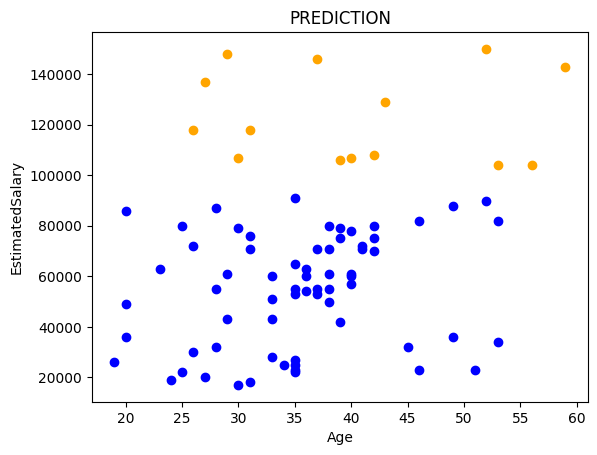

In [31]:
plt.scatter(x_test['Age'][y_pred==1],x_test['EstimatedSalary'][y_pred==1],color="orange")
plt.scatter(x_test['Age'][y_pred==0],x_test['EstimatedSalary'][y_pred==0],color="blue")

plt.title("PREDICTION")
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")

Text(0, 0.5, 'Estimated Salary')

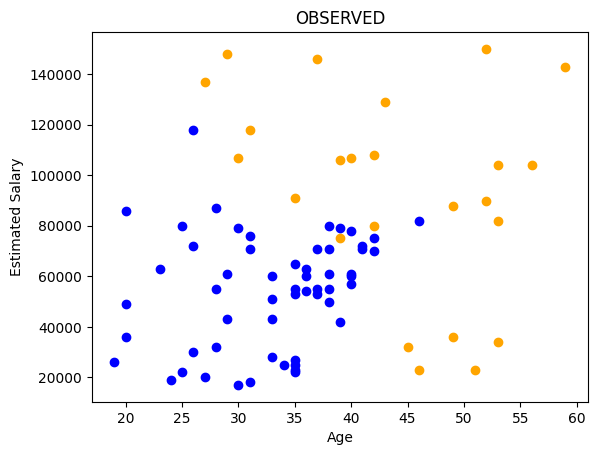

In [32]:
plt.scatter(x_test['Age'][y_test==1],x_test['EstimatedSalary'][y_test==1],color="orange")
plt.scatter(x_test['Age'][y_test==0],x_test['EstimatedSalary'][y_test==0],color="blue")

plt.title("OBSERVED")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")

In [33]:
from sklearn.neighbors import KNeighborsClassifier
# create the model
model_knn = KNeighborsClassifier(n_neighbors=7, weights='uniform')
# train the model
model_knn.fit(x_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## find the best values for hyperparameters

In [34]:
from sklearn.model_selection import GridSearchCV
# create the list of hyper-parameters along with the possible values
parameters = {
    'n_neighbors': range(3, 11),
    'weights': ['uniform', 'distance']
}
# create the grid search
grid_search_knn = GridSearchCV(model_knn, parameters)
# fit the values
grid_search_knn.fit(x_test, y_test)

,estimator,KNeighborsCla...n_neighbors=7)
,param_grid,"{'n_neighbors': range(3, 11), 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [35]:
grid_search_knn.best_params_

{'n_neighbors': 7, 'weights': 'uniform'}

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = model_knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"accuracy = {accuracy:.2f}, precision = {precision:.2f}, recall = {recall:.2f},f1 score = {f1:.2f}")

accuracy = 0.85, precision = 0.75, recall = 0.75,f1 score = 0.75
